In [1]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt



import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.database_manager import get_db



df_all contain whole data (8.7 millions rows with volume)

In [2]:
df_all = get_db().get_all_stocks()
df_all.head()


,ticker,bucket_time,open,high,low,close,volume
0,ADANIENT,2016-07-21 09:40:00,81.099998,81.099998,80.699997,80.699997,38275.0
1,ADANIENT,2016-07-21 09:45:00,80.699997,80.800003,80.400002,80.400002,44151.0
2,ADANIENT,2016-07-21 09:50:00,80.400002,80.500000,80.099998,80.400002,62449.0
3,ADANIENT,2016-07-21 09:55:00,80.400002,80.599998,80.300003,80.599998,39422.0
4,ADANIENT,2016-07-21 10:00:00,80.599998,80.900002,80.599998,80.699997,24347.0


In [3]:
len(df_all)

8725087

In [ ]:
import pandas as pd

def create_synthetic_nifty50_full(df_all: pd.DataFrame, config: dict = None) -> pd.DataFrame:
    """
    Creates synthetic NIFTY50 with official weights.
    Returns EXACT same columns as min_5 table.
    """
    
    if config and "index" in config and "weights" in config["index"]:
        weights = pd.Series(config["index"]["weights"])
    else:
        tickers = sorted(df_all["ticker"].unique())
        weights = pd.Series(1.0 / len(tickers), index=tickers)
    
    df = df_all[["ticker", "bucket_time", "open", "high", "low", "close", "volume"]].copy()
    df["bucket_time"] = pd.to_datetime(df["bucket_time"])
    
    open_wide  = df.pivot(index="bucket_time", columns="ticker", values="open")
    high_wide  = df.pivot(index="bucket_time", columns="ticker", values="high")
    low_wide   = df.pivot(index="bucket_time", columns="ticker", values="low")
    close_wide = df.pivot(index="bucket_time", columns="ticker", values="close")
    volume_wide = df.pivot(index="bucket_time", columns="ticker", values="volume")
    
    synthetic = pd.DataFrame(index=open_wide.index)
    
    synthetic["open"]  = (open_wide  * weights).sum(axis=1)
    synthetic["high"]  = (high_wide  * weights).sum(axis=1)
    synthetic["low"]   = (low_wide   * weights).sum(axis=1)
    synthetic["close"] = (close_wide * weights).sum(axis=1)
    synthetic["volume"] = volume_wide.sum(axis=1)          # volume is summed
    
    synthetic = synthetic.reset_index()
    synthetic["ticker"] = "NIFTY50"
    
    synthetic = synthetic[["ticker", "bucket_time", "open", "high", "low", "close", "volume"]]
    
    print(f"✅ Synthetic NIFTY50 created successfully!")
    print(f"Shape: {synthetic.shape}")
    print(f"Columns: {list(synthetic.columns)}")
    
    return synthetic





In [5]:
real_path = ROOT / "archive" / "NIFTY 50_5minute.csv"
real_df = pd.read_csv(real_path)

real_df["date"] = pd.to_datetime(real_df["date"])
real_df = real_df.sort_values("date").set_index("date")

real_df["real_ret"] = np.log(real_df["close"] / real_df["close"].shift(1))
real_df["real_close_norm"] = real_df["close"] / real_df["close"].iloc[0]
real_df = real_df.dropna()

real_df.head()


,open,high,low,close,volume,real_ret,real_close_norm
date,,,,,,,
2015-01-09 09:20:00,8300.50,8303.00,8293.25,8301.00,0,-0.000024,0.999976
2015-01-09 09:25:00,8301.65,8302.55,8286.80,8294.15,0,-0.000826,0.999151
2015-01-09 09:30:00,8294.10,8295.75,8280.65,8288.50,0,-0.000681,0.998470
2015-01-09 09:35:00,8289.10,8290.45,8278.00,8283.45,0,-0.000609,0.997862
2015-01-09 09:40:00,8283.40,8288.30,8277.40,8285.55,0,0.000253,0.998115


In [6]:
compare = pd.concat(
    [
        synthetic[["synthetic_ret", "synthetic_close_norm"]],
        real_df[["real_ret", "real_close_norm"]],
    ],
    axis=1,
    join="inner",
).dropna()

print(compare.shape)
compare.head()


NameError: name 'synthetic' is not defined

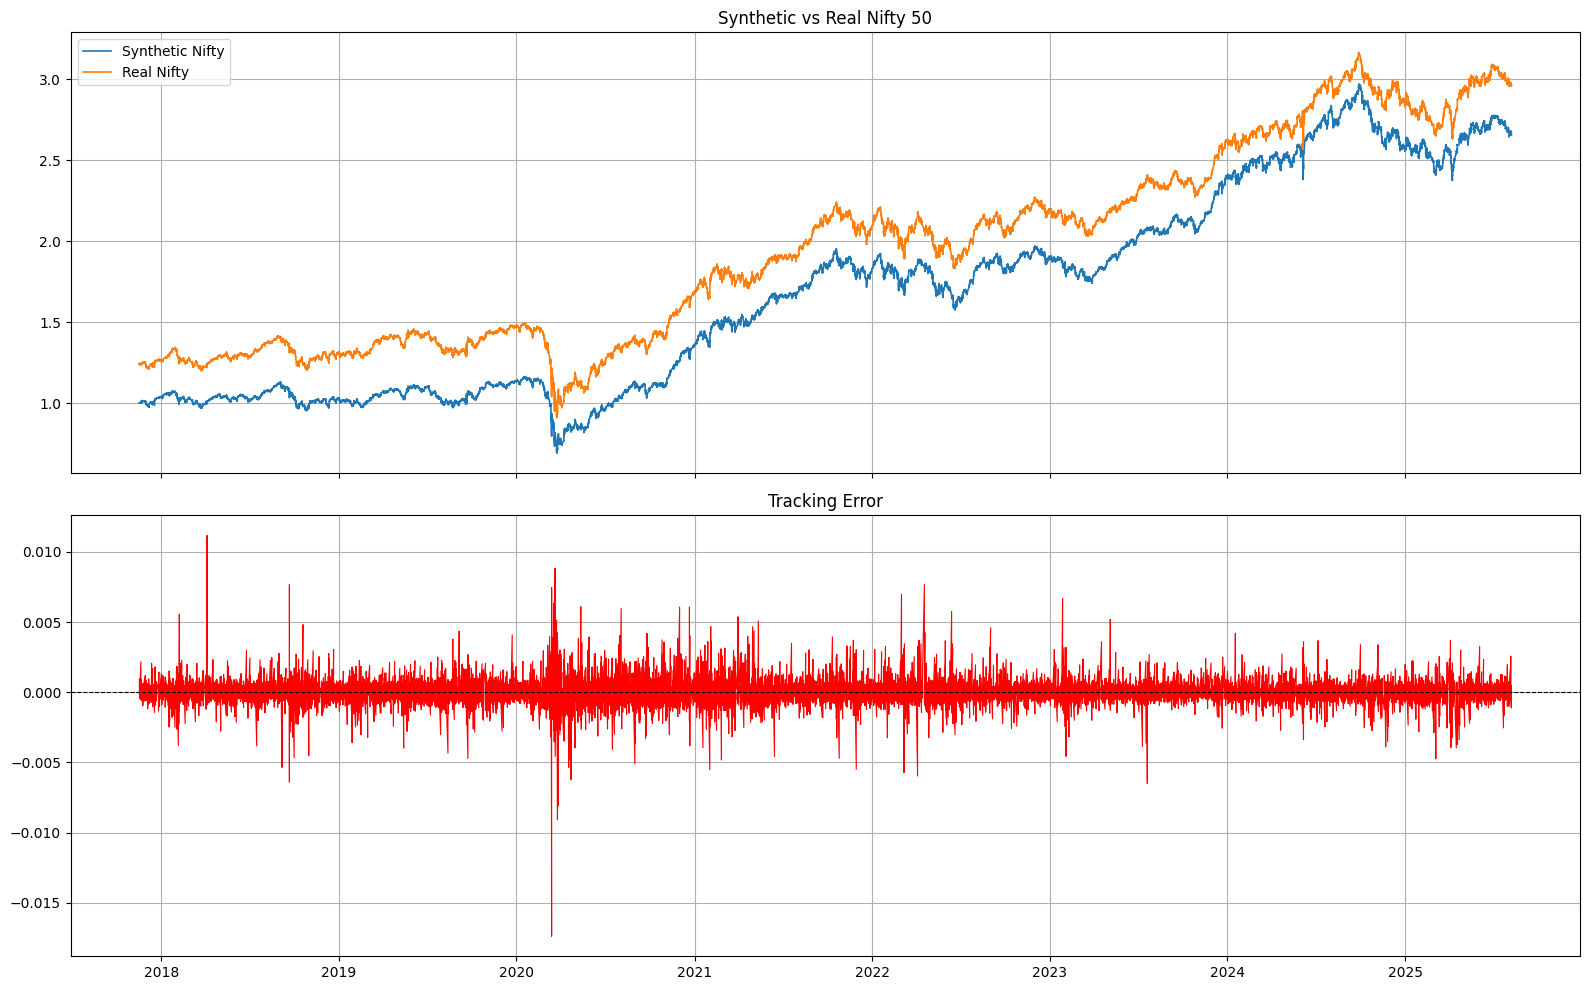

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(compare.index, compare["synthetic_close_norm"], label="Synthetic Nifty", lw=1.2)
axes[0].plot(compare.index, compare["real_close_norm"], label="Real Nifty", lw=1.2)
axes[0].set_title("Synthetic vs Real Nifty 50")
axes[0].legend()
axes[0].grid(True)

compare["tracking_error"] = compare["synthetic_ret"] - compare["real_ret"]
axes[1].plot(compare.index, compare["tracking_error"], color="red", lw=0.8)
axes[1].axhline(0, color="black", ls="--", lw=0.8)
axes[1].set_title("Tracking Error")
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
corr = compare["synthetic_ret"].corr(compare["real_ret"])
rmse = np.sqrt(((compare["synthetic_ret"] - compare["real_ret"]) ** 2).mean())
dir_acc = (np.sign(compare["synthetic_ret"]) == np.sign(compare["real_ret"])).mean()

print("Correlation:", round(corr, 6))
print("RMSE:", round(rmse, 6))
print("Directional Accuracy:", round(dir_acc, 4))


Correlation: 0.953465
RMSE: 0.000373
Directional Accuracy: 0.8707


In [ ]:


tickers = sorted(df_all["ticker"].unique())

df_px = df_all.copy()
df_px["bucket_time"] = pd.to_datetime(df_px["bucket_time"])

counts = df_px.groupby("bucket_time")["ticker"].transform("nunique")
df_full = df_px[counts == len(tickers)].copy()

final_ohlc = (
    df_full[["ticker", "bucket_time", "open", "high", "low", "close", "volume"]]
    .sort_values(["bucket_time", "ticker"])
    .reset_index(drop=True)
)

final_ohlc.to_csv("nifty50_ohlc_sorted_by_time.csv", index=False)

print(final_ohlc.shape)
final_ohlc.head()


In [ ]:
final_ohlc = (
    df_all[["ticker", "bucket_time", "open", "high", "low", "close", "volume"]]
    .assign(bucket_time=lambda x: pd.to_datetime(x["bucket_time"]))
    .sort_values(["bucket_time", "ticker"])
    .reset_index(drop=True)
)

final_ohlc.to_csv("nifty50_ohlc_sorted_by_time.csv", index=False)

print(final_ohlc.shape)
final_ohlc.head()
